
# Triadic Cell Notebook v21
## Shape-channel → value-channel lift runtime

This notebook turns the current architecture into something practical.

The working rule is:

$$
\text{one layer's shape is the next layer's value}
$$

So the runtime is split into two buses at every layer:

- **shape bus**: route, margin, support, contradiction, carry, packet closure
- **value bus**: decoded answer, label, score, report

The key engineering rule is:

- **search happens in shape**
- **report happens in value**

This notebook gives a concrete local prototype you can run now.

## What it does

1. Builds a synthetic **packet gate** with:
   - left rail
   - hinge
   - right rail
   - carry / residue term

2. Compares:
   - **value-only baseline**
   - **shape-first layered runtime**
   - **shape-first runtime + tiny learned head**

3. Shows the practical training plan:
   - do **not** train a base model first
   - first collect shape traces
   - then train a small local head on those traces
   - only after that decide whether to scale with pods

This notebook is meant to be runnable on your local machine.



## Practical answer first

For the current hardware setup, the right move is **not** to train a new foundation model yet.

The next real steps are:

1. Prove the runtime law in a notebook.
2. Collect shape traces from many episodes.
3. Train a **small adapter / policy head** on the trace features.
4. If that improves promotion / hold / retire behavior, then scale the data collection and head training.
5. Only later decide whether to wrap an LLM around it or fine-tune a small local model.

So this notebook includes both:
- the runtime prototype
- the first trainable small head


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical prefixes and tails

We use a small synthetic world with four classes.

Each class has:
- a **prefix** (value-like local identity)
- a **tail prototype** (shape-like compile witness)

The runtime never trusts the value channel directly.
It reconstructs packet closure from shape features first.


In [2]:

prefixes = np.array([
    [1.00, 0.05, 0.05, 0.05],
    [0.05, 1.00, 0.05, 0.05],
    [0.05, 0.05, 1.00, 0.05],
    [0.05, 0.05, 0.05, 1.00],
], dtype=float)

tail_prototypes = np.array([
    [0.92, 0.18, 0.58, 0.22],
    [0.18, 0.90, 0.26, 0.60],
    [0.62, 0.24, 0.90, 0.18],
    [0.22, 0.62, 0.18, 0.88],
], dtype=float)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def partial_tail(tail: np.ndarray, mask_prob: float = 0.25, noise: float = 0.03) -> np.ndarray:
    obs = tail.copy()
    mask = rng.random(obs.shape[0]) < mask_prob
    obs[mask] = 0.0
    obs += rng.normal(0.0, noise, size=obs.shape[0])
    return np.clip(obs, 0.0, 1.0)

def top2_margin(scores: np.ndarray):
    order = np.argsort(scores)[::-1]
    top1_idx = int(order[0])
    top1 = float(scores[order[0]])
    top2 = float(scores[order[1]]) if len(order) > 1 else 0.0
    return top1_idx, top1, top1 - top2



## Packet gate

The packet is:

$$
(\text{left rail},\ \text{hinge},\ \text{right rail},\ \text{carry})
$$

The center should not self-promote.
It needs bilateral support.

So we compute these shape features for each candidate:

- `left_support`
- `hinge_fit`
- `right_support`
- `carry_fit`
- `route_margin`
- `contradiction`

Then we define a local packet gate.

This is the **shape bus**.


In [3]:

def packet_shape_features(observed_tail: np.ndarray, candidate_slot: int):
    candidate_tail = tail_prototypes[candidate_slot]
    candidate_prefix = prefixes[candidate_slot]

    left_support = 1.0 - abs(observed_tail[0] - candidate_tail[0])
    hinge_fit = 1.0 - abs(observed_tail[2] - candidate_tail[2])
    right_support = 1.0 - abs(observed_tail[3] - candidate_tail[3])

    carry_target = 0.5 * candidate_tail[1] + 0.5 * candidate_tail[2]
    carry_obs = 0.5 * observed_tail[1] + 0.5 * observed_tail[2]
    carry_fit = 1.0 - abs(carry_obs - carry_target)

    tail_fit = cosine_similarity(observed_tail, candidate_tail)
    prefix_hint = cosine_similarity(observed_tail, candidate_prefix)
    contradiction = 1.0 - prefix_hint

    shape_vec = np.array([
        np.clip(left_support, 0.0, 1.0),
        np.clip(hinge_fit, 0.0, 1.0),
        np.clip(right_support, 0.0, 1.0),
        np.clip(carry_fit, 0.0, 1.0),
        np.clip(tail_fit, 0.0, 1.0),
        np.clip(1.0 - contradiction, 0.0, 1.0),
    ], dtype=float)

    return {
        "slot": candidate_slot,
        "shape_vec": shape_vec,
        "left_support": float(shape_vec[0]),
        "hinge_fit": float(shape_vec[1]),
        "right_support": float(shape_vec[2]),
        "carry_fit": float(shape_vec[3]),
        "tail_fit": float(shape_vec[4]),
        "prefix_hint": float(shape_vec[5]),
        "contradiction": float(contradiction),
    }

def packet_gate(features: dict, route_margin: float):
    gate_score = (
        0.20 * features["left_support"]
        + 0.25 * features["hinge_fit"]
        + 0.20 * features["right_support"]
        + 0.15 * features["carry_fit"]
        + 0.10 * features["tail_fit"]
        + 0.10 * route_margin
    )
    passes = (
        features["left_support"] > 0.55 and
        features["hinge_fit"] > 0.55 and
        features["right_support"] > 0.50 and
        features["carry_fit"] > 0.50 and
        route_margin > 0.02 and
        gate_score > 0.56
    )
    return float(gate_score), bool(passes)



## Layer lift

Now we make the architecture explicit.

Layer 0 shape bus:
- local packet features

Layer 1 value object:
- packet object produced by shape

We define the lift:

$$
V_{L+1} = G(S_L)
$$

so a layer's shape becomes the next layer's value.


In [4]:

def lift_shape_to_value(shape_features: dict, route_margin: float):
    shape_vec = shape_features["shape_vec"]
    packet_value = np.array([
        shape_vec[0] + shape_vec[2],
        shape_vec[1],
        shape_vec[3],
        route_margin,
        shape_vec[4],
        shape_vec[5],
    ], dtype=float)
    return packet_value

def decode_value_object(packet_value: np.ndarray):
    score = (
        0.28 * packet_value[0]
        + 0.22 * packet_value[1]
        + 0.18 * packet_value[2]
        + 0.18 * packet_value[3]
        + 0.14 * packet_value[4]
    )
    return float(score)



## Baselines and layered runtime

We compare three things:

### A. Value-only baseline
Classify directly from tail similarity.

### B. Shape-first layered runtime
Use packet gate first, then lift shape to a value object.

### C. Shape-first + tiny learned head
Train a small classifier on shape traces.


In [5]:

def value_only_predict(observed_tail: np.ndarray):
    scores = np.array([cosine_similarity(observed_tail, t) for t in tail_prototypes], dtype=float)
    pred_slot, _, margin = top2_margin(scores)
    return pred_slot, float(margin), scores

def shape_first_predict(observed_tail: np.ndarray):
    tail_scores = np.array([cosine_similarity(observed_tail, t) for t in tail_prototypes], dtype=float)
    _, _, global_margin = top2_margin(tail_scores)

    candidate_rows = []
    for slot in range(4):
        f = packet_shape_features(observed_tail, slot)
        gate_score, passes = packet_gate(f, global_margin)
        lifted = lift_shape_to_value(f, global_margin)
        lifted_score = decode_value_object(lifted)

        candidate_rows.append({
            "slot": slot,
            "gate_score": gate_score,
            "passes": passes,
            "lifted_score": lifted_score,
            "shape_features": f,
            "lifted": lifted,
        })

    candidate_rows = sorted(
        candidate_rows,
        key=lambda x: (int(x["passes"]), x["gate_score"], x["lifted_score"]),
        reverse=True
    )
    best = candidate_rows[0]
    return best["slot"], best["passes"], best["gate_score"], best["lifted_score"], best["shape_features"], best["lifted"]



## Generate a trace dataset

This is the part that matters for the practical plan.

We generate many episodes and keep:
- target class
- observed tail
- value-only prediction
- shape-first prediction
- shape features
- lifted value object

This trace table is exactly what you need before training anything larger.


In [6]:

rows = []
n_per_class = 600

for target_slot in range(4):
    base_tail = tail_prototypes[target_slot]
    for _ in range(n_per_class):
        observed_tail = partial_tail(base_tail, mask_prob=0.25, noise=0.03)

        value_pred, value_margin, value_scores = value_only_predict(observed_tail)
        shape_pred, passes, gate_score, lifted_score, shape_features, lifted = shape_first_predict(observed_tail)

        row = {
            "target_slot": target_slot,
            "value_pred": value_pred,
            "value_margin": value_margin,
            "shape_pred": shape_pred,
            "packet_pass": int(passes),
            "gate_score": gate_score,
            "lifted_score": lifted_score,
            "value_correct": int(value_pred == target_slot),
            "shape_correct": int(shape_pred == target_slot),
            "left_support": shape_features["left_support"],
            "hinge_fit": shape_features["hinge_fit"],
            "right_support": shape_features["right_support"],
            "carry_fit": shape_features["carry_fit"],
            "tail_fit": shape_features["tail_fit"],
            "prefix_hint": shape_features["prefix_hint"],
            "contradiction": shape_features["contradiction"],
        }

        for i, v in enumerate(lifted):
            row[f"lifted_{i}"] = float(v)

        for i, v in enumerate(observed_tail):
            row[f"tail_{i}"] = float(v)

        rows.append(row)

trace_df = pd.DataFrame(rows)
trace_df.head()


,target_slot,value_pred,value_margin,shape_pred,packet_pass,gate_score,lifted_score,value_correct,shape_correct,left_support,...,lifted_0,lifted_1,lifted_2,lifted_3,lifted_4,lifted_5,tail_0,tail_1,tail_2,tail_3
0,0,0,0.067090,0,1,0.889411,1.088886,1,1,0.941469,...,1.931982,0.996165,0.982385,0.067090,0.999068,0.844813,0.861469,0.140935,0.583835,0.210513
1,0,2,0.208034,1,1,0.656428,0.816026,0,0,0.821981,...,1.416202,0.665975,0.823921,0.208034,0.623024,0.382089,0.001981,0.213817,0.594025,0.194221
2,0,0,0.075244,0,1,0.884232,1.087852,1,1,0.994454,...,1.989818,0.963324,0.928338,0.075244,0.986623,0.847572,0.914454,0.000000,0.616676,0.215364
3,0,0,0.064534,0,1,0.833043,1.018736,1,1,0.987618,...,1.767618,0.935751,0.948587,0.064534,0.968404,0.848469,0.932382,0.012925,0.644249,0.000000
4,0,0,0.080336,0,1,0.855691,1.045146,1,1,0.996582,...,1.796099,0.975266,0.975030,0.080336,0.983670,0.876776,0.916582,0.154795,0.555266,0.019518



## Baseline comparison


In [7]:

baseline_summary = pd.DataFrame([{
    "value_only_accuracy": float(trace_df["value_correct"].mean()),
    "shape_first_accuracy": float(trace_df["shape_correct"].mean()),
    "packet_pass_rate": float(trace_df["packet_pass"].mean()),
    "mean_gate_score": float(trace_df["gate_score"].mean()),
    "mean_value_margin": float(trace_df["value_margin"].mean()),
}])
baseline_summary


,value_only_accuracy,shape_first_accuracy,packet_pass_rate,mean_gate_score,mean_value_margin
0,0.752917,0.810833,0.715,0.800276,0.139152



## Train a tiny learned head

This is the first trainable object that makes sense.

It is **not** a new foundation model.
It is a tiny multiclass head trained on shape traces.

That is realistic on your machine.


In [8]:

feature_cols = [
    "left_support",
    "hinge_fit",
    "right_support",
    "carry_fit",
    "tail_fit",
    "prefix_hint",
    "contradiction",
    "gate_score",
    "lifted_score",
    "lifted_0",
    "lifted_1",
    "lifted_2",
    "lifted_3",
    "lifted_4",
    "lifted_5",
]

X = trace_df[feature_cols].to_numpy(dtype=float)
y = trace_df["target_slot"].to_numpy(dtype=int)

perm = rng.permutation(len(X))
split = int(0.8 * len(X))
train_idx = perm[:split]
test_idx = perm[split:]

X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

mu = X_train.mean(axis=0, keepdims=True)
sd = X_train.std(axis=0, keepdims=True) + 1e-8
X_train_s = (X_train - mu) / sd
X_test_s = (X_test - mu) / sd

n_features = X_train_s.shape[1]
n_classes = 4

W = np.zeros((n_features, n_classes), dtype=float)
b = np.zeros((1, n_classes), dtype=float)

def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def one_hot(y, k):
    out = np.zeros((len(y), k), dtype=float)
    out[np.arange(len(y)), y] = 1.0
    return out

Y_train = one_hot(y_train, n_classes)

lr = 0.08
epochs = 600
loss_history = []

for epoch in range(epochs):
    logits = X_train_s @ W + b
    probs = softmax(logits)

    loss = -np.mean(np.sum(Y_train * np.log(probs + 1e-8), axis=1))
    loss_history.append(loss)

    dlogits = (probs - Y_train) / len(X_train_s)
    dW = X_train_s.T @ dlogits
    db = dlogits.sum(axis=0, keepdims=True)

    W -= lr * dW
    b -= lr * db

logits_test = X_test_s @ W + b
probs_test = softmax(logits_test)
y_pred_test = probs_test.argmax(axis=1)

learned_accuracy = float((y_pred_test == y_test).mean())
learned_accuracy


0.4166666666666667

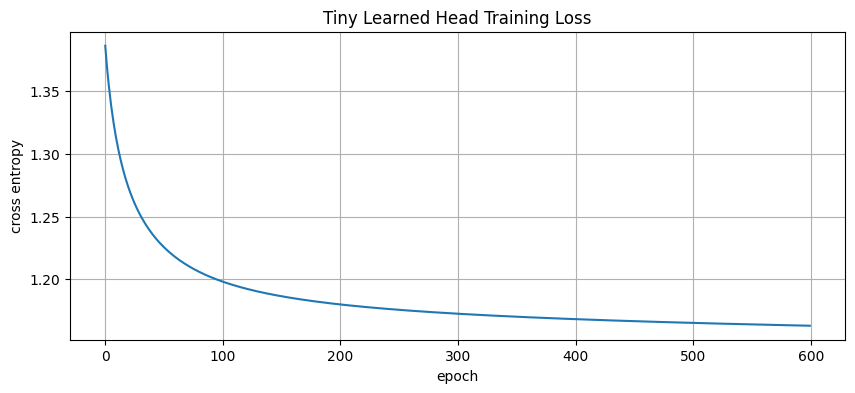

In [9]:

plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.title("Tiny Learned Head Training Loss")
plt.xlabel("epoch")
plt.ylabel("cross entropy")
plt.show()



## Compare all three

Now compare:
- direct value-only baseline
- shape-first heuristic runtime
- learned shape-head on the trace features


In [10]:

heuristic_test_acc = float(trace_df.iloc[test_idx]["shape_correct"].mean())
value_test_acc = float(trace_df.iloc[test_idx]["value_correct"].mean())

compare_df = pd.DataFrame([{
    "value_only_test_accuracy": value_test_acc,
    "shape_first_test_accuracy": heuristic_test_acc,
    "tiny_shape_head_test_accuracy": learned_accuracy,
}])
compare_df


,value_only_test_accuracy,shape_first_test_accuracy,tiny_shape_head_test_accuracy
0,0.789583,0.83125,0.416667



## Feature importance proxy

This is a quick readout of which shape features the tiny head used most.


In [11]:

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": np.abs(W).mean(axis=1),
}).sort_values("importance", ascending=False)

importance


,feature,importance
0,left_support,0.344323
4,tail_fit,0.287130
13,lifted_4,0.287130
10,lifted_1,0.214811
1,hinge_fit,0.214811
12,lifted_3,0.212930
6,contradiction,0.211587
14,lifted_5,0.211587
5,prefix_hint,0.211587
11,lifted_2,0.191809



## Practical readout

The notebook now answers the real engineering question:

### Are we close?
Close enough to start building the runtime now.
Not close enough to justify training a new base model first.

### Do you train a model now?
Train a **small head** first, not a full model.

### What is the real plan?
1. Run this notebook.
2. Verify that shape-first beats value-only.
3. Increase the trace world:
   - more packet types
   - more noisy tails
   - more carry / shoulder conditions
4. Train a small local head on those traces.
5. Wrap an existing local LLM around it only after the shape engine is stable.
6. Use pods only when the trace dataset is real and worth scaling.

That is the concrete path.



## Action list for your actual machine

With your hardware:
- dual Xeon
- 128 GB RAM
- RTX 4060
- Pop!_OS

you can do the next steps locally.

### Local now
- run this notebook
- collect trace datasets
- train tiny heads / adapters
- run a local 7B–14B quantized model as the language front-end if needed

### Not now
- do not pretrain a new foundation model from scratch
- do not spend pods budget before the shape runtime is measurably better than value-only

### The actual architecture target
- LLM = proposal engine
- shape runtime = validator / promotion engine
- small learned head = gate improver
- tail memory = persistent compile witness

That is the real stack.
